In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor 

sns.set(style="whitegrid")

In [ ]:
# load dataset
df = pd.read_csv("spotify_project/dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

In [ ]:
# data overview
print(df.info())
print(df.describe())

#checking missing values
print("\nMissing Values:\n", df.isnull().sum())

In [ ]:
#data cleaning 

#drop duplicates if any 
df = df.drop_duplicates()

#fill missing values
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
#feature selection 

features = [
    "danceability", "energy","loudness","speechiness","acousticness","instrumentalness",
    "valence","tempo"
]

In [ ]:
#exploratory data analysis 
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

#scatter plots 
plt.figure()
sns.scatterplot(x="energy", y="popularity", data=df)
plt.title("Energy vs Popularity")
plt.show()

plt.figure()
sns.scatterplot(x="danceability", y="popularity", data=df)
plt.title("Danceability vs Popularity")
plt.show()


               energy   loudness  speechiness  acousticness  instrumentalness  \
track_genre                                                                     
acoustic     0.435368  -9.447843     0.043247      0.566816          0.038336   
afrobeat     0.702812  -7.789353     0.086579      0.270860          0.253483   
alt-rock     0.754173  -6.191489     0.055071      0.122162          0.054097   
alternative  0.720030  -6.078777     0.070101      0.147820          0.038159   
ambient      0.237162 -18.601365     0.041562      0.776790          0.676221   

              valence       tempo  
track_genre                        
acoustic     0.424023  119.010624  
afrobeat     0.698619  119.213337  
alt-rock     0.518260  124.634404  
alternative  0.495570  122.232394  
ambient      0.167498  111.113129  


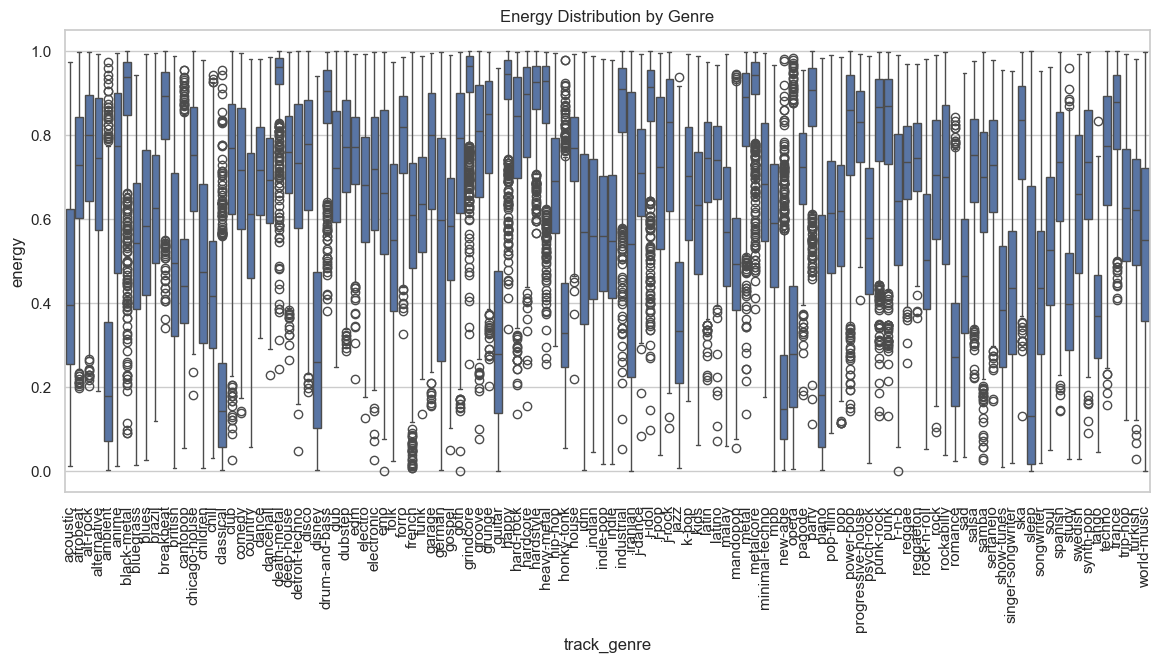

In [30]:
#genre analysis
if "track_genre" in df.columns:
    genre_avg = df.groupby("track_genre")[features].mean()
    print(genre_avg.head())

    plt.figure(figsize=(14,6))
    sns.boxplot(x="track_genre", y="energy", data=df)
    plt.xticks(rotation=90)
    plt.title("Energy Distribution by Genre")
    plt.show()

In [27]:
# print actual columns

print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [28]:
#replace features list with safe version

expected_features=[
    "danceabilltiy",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo"
]

features = [col for col in expected_features if col in df.columns]

print("using features:", features)

using features: ['energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']


In [29]:
#check missing column

missing = [col for col in expected_features if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['danceabilltiy']


In [32]:
#trending songs analysis 

trending = df[df["popularity"]>80]

print("\nTrending songs mean:\n", trending.mean(numeric_only=True))
print("\nOverall mean: \n", df.mean(numeric_only=True))



Trending songs mean:
 Unnamed: 0           60485.560797
popularity              84.614256
duration_ms         211630.045073
explicit                 0.253669
danceability             0.658111
energy                   0.679426
key                      5.388889
loudness                -6.127299
mode                     0.588050
speechiness              0.081458
acousticness             0.188535
instrumentalness         0.026476
liveness                 0.168345
valence                  0.507980
tempo                  118.426755
time_signature           3.947589
dtype: float64

Overall mean: 
 Unnamed: 0           56999.500000
popularity              33.238535
duration_ms         228029.153114
explicit                 0.085500
danceability             0.566800
energy                   0.641383
key                      5.309140
loudness                -8.258960
mode                     0.637553
speechiness              0.084652
acousticness             0.314910
instrumentalness         0.

In [35]:
#data scaling

X =df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

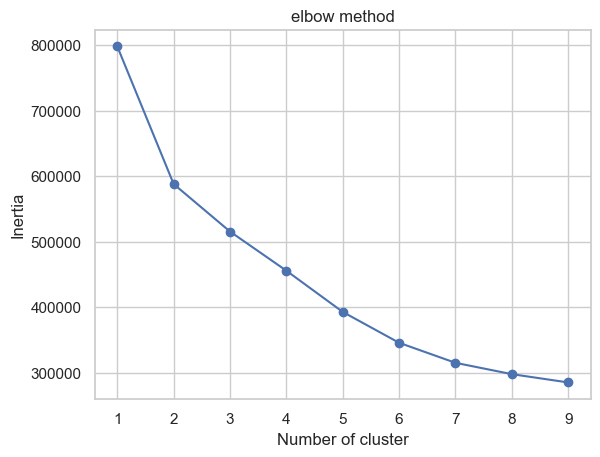

In [39]:
#elbow method

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.title("elbow method")
plt.show()


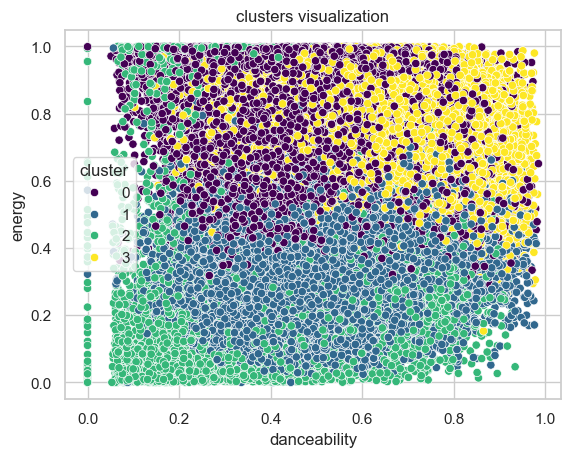


cluster summary:
            energy   loudness  speechiness  acousticness  instrumentalness  \
cluster                                                                     
0        0.790618  -6.220050     0.084439      0.063986          0.249726   
1        0.403161 -10.490961     0.084114      0.661133          0.025927   
2        0.224386 -19.701295     0.054850      0.789680          0.805492   
3        0.765669  -6.018270     0.091380      0.187997          0.031530   

          valence       tempo  
cluster                        
0        0.288071  132.948240  
1        0.416701  112.228440  
2        0.214850  105.699447  
3        0.708865  123.583108  


In [45]:
#Kmeans Clustering

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

#cluster visualization
plt.figure()
sns.scatterplot(x=df["danceability"], y=df["energy"], hue=df["cluster"], palette="viridis")
plt.title("clusters visualization")
plt.show()

#cluster summary 
cluster_summary = df.groupby("cluster")[features].mean()
print("\ncluster summary:\n", cluster_summary)

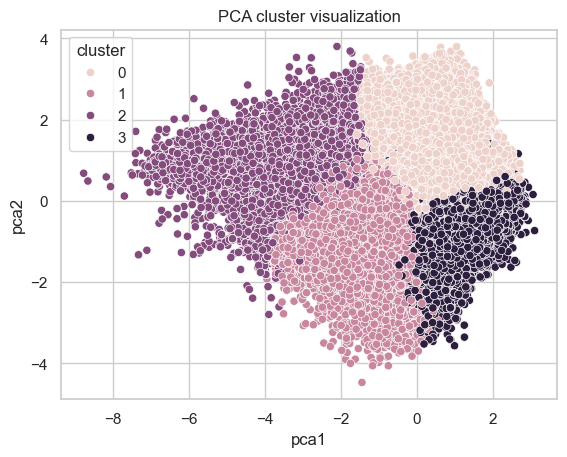

In [47]:
#pca visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure()
sns.scatterplot(x="pca1", y="pca2", hue="cluster", data=df)
plt.title("PCA cluster visualization")
plt.show()

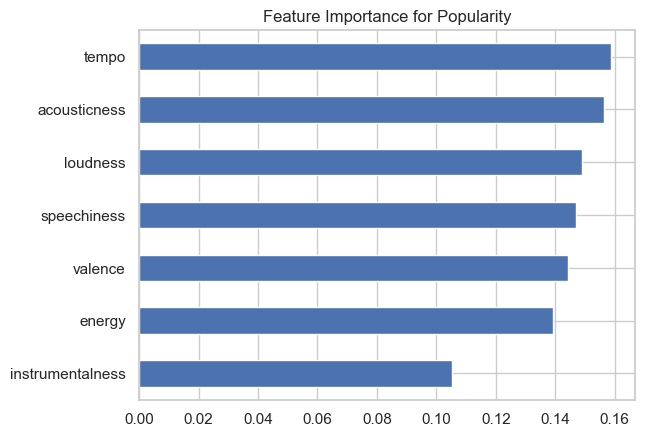

In [49]:
#feature importance 

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X, df["popularity"])

importances = pd.Series(model.feature_importances_, index=features)

plt.figure()
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance for Popularity")
plt.show()

In [50]:
#insights 

print("""
Key Insights:
- Identify which features correlate most with popularity
- Compare trending vs overall songs
- Observe cluster patterns (types of songs)
- Understand genre-based differences
""")


Key Insights:
- Identify which features correlate most with popularity
- Compare trending vs overall songs
- Observe cluster patterns (types of songs)
- Understand genre-based differences



In [51]:
print(importances)

energy              0.139284
loudness            0.149009
speechiness         0.146851
acousticness        0.156289
instrumentalness    0.105363
valence             0.144281
tempo               0.158924
dtype: float64
